# US-05 — Avaliação Comparativa: Transformer vs GAT

**Objetivo:** Comparar rigorosamente os dois modelos treinados para classificação de falhas em rolamentos (EGB-250), avaliando acurácia, F1, AUC-ROC, matrizes de confusão, curvas ROC, consistência temporal (DTW) e eficiência computacional.

## Sumário dos Modelos

| Aspecto | VibrationTransformer | VibrationGAT |
|---|---|---|
| Parâmetros treináveis | 67.524 | 4.004 |
| Acurácia (test) | **97.87%** | **94.41%** |
| Ambiente de treino | RTX 3050 | RTX 3050 |
| Épocas treinadas | 16 (early stopping) | 14 (early stopping) |
| Tempo de treino | 9.500s (~2.64h) | 22.1s |
| Best val_loss | 0.0781 | 0.2828 |
| Checkpoint | `models/transformer_best.pt` | `models/gat_best.pt` |

## 1. Setup

In [1]:
import os, sys, json, time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
if IN_COLAB:
    COLAB_REPO = Path("/content/anomaly_detection_comparison")
    if not COLAB_REPO.exists():
        os.system("git clone https://github.com/camaro0729/anomaly_detection_comparison.git /content/anomaly_detection_comparison")
    PROJECT_ROOT = COLAB_REPO
else:
    PROJECT_ROOT = Path(".").resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.transformer import VibrationTransformer, make_dataloaders, epoch_step
from src.models.gat import VibrationGAT, make_graph_dataloaders, epoch_step_gat
from src.evaluation import compute_metrics, dtw_consistency, build_comparison_table, run_inference_transformer, run_inference_gat
from torch_geometric.loader import DataLoader as PyGDataLoader

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["Normal (P1)", "Inner Race (P2)", "Roller Element (P3)", "Outer Race (P4)"]
WINDOWS_PER_RUN = 243
FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Device: {DEVICE}")
print(f"Project root: {PROJECT_ROOT}")

Device: cuda
Project root: /home/camara/workspace/projetos_educacionais/anomaly_detection_comparison


## 2. Carregar Dados de Teste

In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "processed"

X_test = np.load(DATA_DIR / "X_test.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

graphs_test = torch.load(DATA_DIR / "graphs_test.pt", weights_only=False)
for i, g in enumerate(graphs_test):
    g.y = torch.tensor(int(y_test[i]), dtype=torch.long)

X_dummy = np.zeros((1, 4, 4096), dtype=np.float32)
y_dummy = np.zeros(1, dtype=np.int64)
_, test_loader_t = make_dataloaders(X_dummy, y_dummy, X_test, y_test, batch_size=64)
test_loader_g = PyGDataLoader(graphs_test, batch_size=64, shuffle=False)

print(f"Test samples: {len(y_test)}")
print(f"Classes: {dict(zip(range(4), np.bincount(y_test)))}")

Test samples: 2916
Classes: {0: 729, 1: 729, 2: 729, 3: 729}


## 3. Carregar Modelos

In [3]:
MODELS_DIR = PROJECT_ROOT / "models"

# Transformer (phase: minimal — d_model=64, nhead=4, layers=2, dim_ff=128)
model_t = VibrationTransformer(
    n_channels=4, window_size=4096, n_classes=4,
    d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.0,
).to(DEVICE)
model_t.load_state_dict(torch.load(MODELS_DIR / "transformer_best.pt", weights_only=True))
model_t.eval()
n_params_t = sum(p.numel() for p in model_t.parameters() if p.requires_grad)

# GAT (phase: minimal — hidden=32, heads=2, layers=2)
model_g = VibrationGAT(
    n_feat=24, n_classes=4, hidden=32, heads=2, num_layers=2, dropout=0.0,
).to(DEVICE)
model_g.load_state_dict(torch.load(MODELS_DIR / "gat_best.pt", weights_only=True))
model_g.eval()
n_params_g = sum(p.numel() for p in model_g.parameters() if p.requires_grad)

print(f"Transformer: {n_params_t:,} trainable parameters")
print(f"GAT:         {n_params_g:,} trainable parameters")

Transformer: 67,524 trainable parameters
GAT:         4,004 trainable parameters


## 4. Inferência no Conjunto de Teste

In [4]:
y_true, y_pred_t, y_prob_t = run_inference_transformer(model_t, test_loader_t, DEVICE)
_,      y_pred_g, y_prob_g = run_inference_gat(model_g, test_loader_g, DEVICE)

print(f"Transformer accuracy: {(y_pred_t == y_true).mean()*100:.2f}%")
print(f"GAT accuracy:         {(y_pred_g == y_true).mean()*100:.2f}%")

Transformer accuracy: 97.87%
GAT accuracy:         94.41%


## 5. Métricas Detalhadas

In [5]:
metrics_t = compute_metrics(y_true, y_pred_t, y_prob_t)
metrics_g = compute_metrics(y_true, y_pred_g, y_prob_g)

print("=== Transformer ===")
print(classification_report(y_true, y_pred_t, target_names=CLASS_NAMES))
print("=== GAT ===")
print(classification_report(y_true, y_pred_g, target_names=CLASS_NAMES))

=== Transformer ===
                     precision    recall  f1-score   support

        Normal (P1)       0.99      0.99      0.99       729
    Inner Race (P2)       0.93      0.99      0.96       729
Roller Element (P3)       1.00      0.93      0.96       729
    Outer Race (P4)       1.00      1.00      1.00       729

           accuracy                           0.98      2916
          macro avg       0.98      0.98      0.98      2916
       weighted avg       0.98      0.98      0.98      2916

=== GAT ===
                     precision    recall  f1-score   support

        Normal (P1)       0.99      0.98      0.99       729
    Inner Race (P2)       0.94      0.85      0.89       729
Roller Element (P3)       0.89      0.99      0.93       729
    Outer Race (P4)       0.97      0.96      0.96       729

           accuracy                           0.94      2916
          macro avg       0.95      0.94      0.94      2916
       weighted avg       0.95      0.94      0.

## 6. Matrizes de Confusão

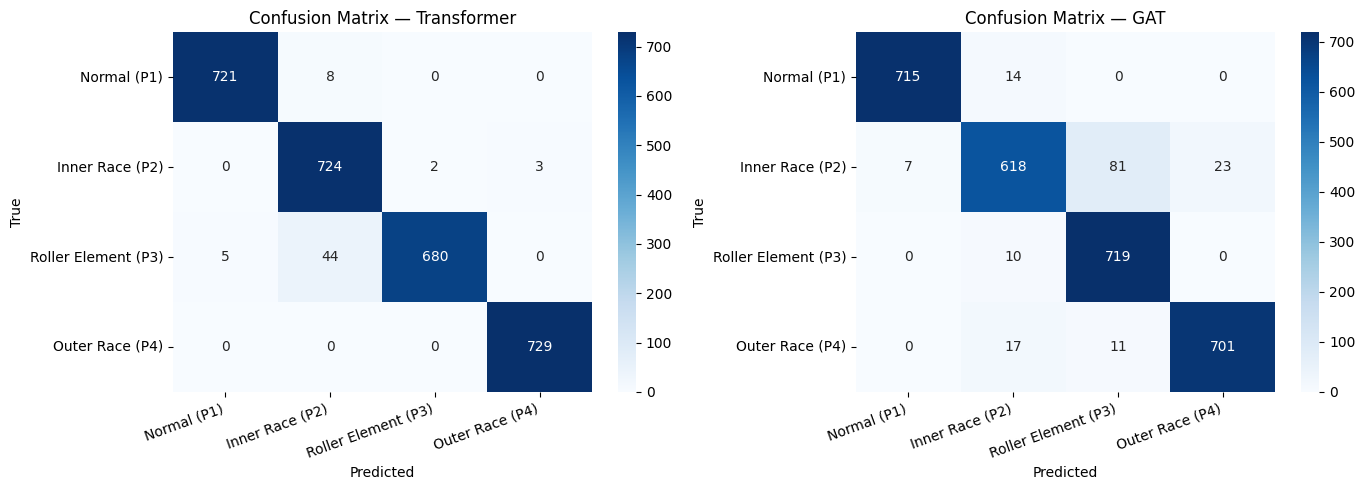

Saved: docs/figures/05_confusion_matrices.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_t, "Transformer"),
    (axes[1], y_pred_g, "GAT"),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {title}")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "05_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: docs/figures/05_confusion_matrices.png")

## 7. Curvas ROC

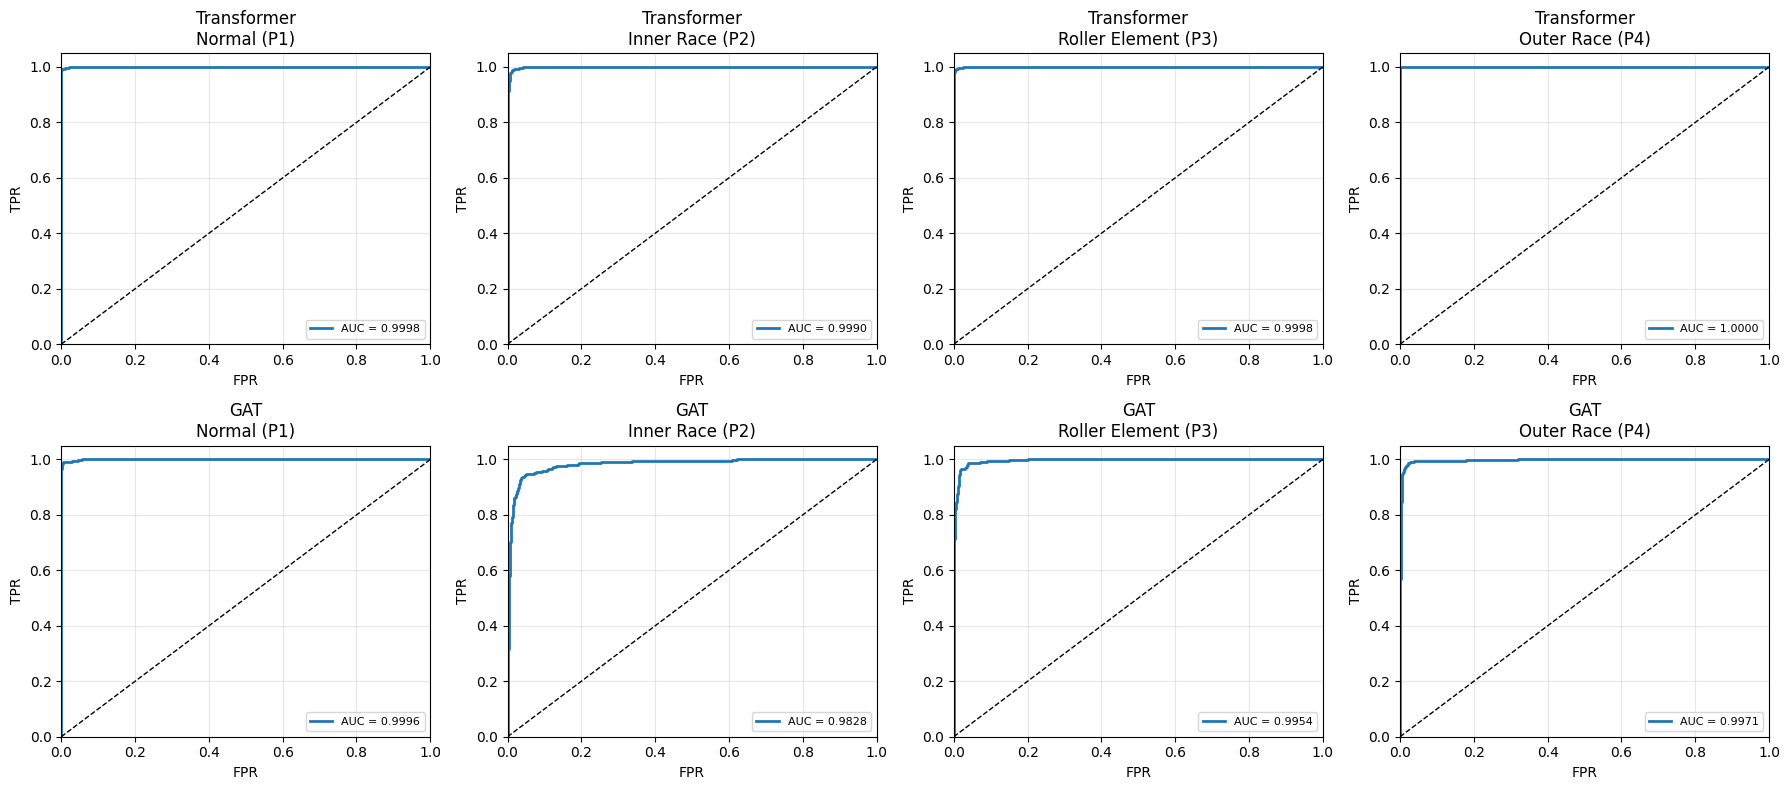

Saved: docs/figures/05_roc_curves.png


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for row, (y_prob, model_name) in enumerate([(y_prob_t, "Transformer"), (y_prob_g, "GAT")]):
    for c, class_name in enumerate(CLASS_NAMES):
        ax = axes[row, c]
        y_bin = (y_true == c).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, y_prob[:, c])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1)
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.set_title(f"{model_name}\n{class_name}")
        ax.legend(loc="lower right", fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.05])

plt.tight_layout()
fig.savefig(FIGURES_DIR / "05_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: docs/figures/05_roc_curves.png")

## 8. Consistência Temporal (DTW)

In [ ]:
dtw_t = dtw_consistency(y_true, y_pred_t, windows_per_run=WINDOWS_PER_RUN)
dtw_g = dtw_consistency(y_true, y_pred_g, windows_per_run=WINDOWS_PER_RUN)

n_runs = len(y_true) // WINDOWS_PER_RUN
print(f"Número de runs no teste: {n_runs}")
print(f"Windows por run: {WINDOWS_PER_RUN}")
print(f"DTW médio — Transformer: {dtw_t:.2f}")
print(f"DTW médio — GAT:         {dtw_g:.2f}")

# Plot DTW per run
from src.evaluation import dtw_distance
import json

# Load actual test run numbers from split config
_cfg = json.load(open(DATA_DIR / "split_config.json"))
test_run_labels = [f"R{r}" for r in _cfg["test"]]  # e.g. ["R13", "R4", "R7"] with seed=42

dtw_per_run_t = [dtw_distance(y_true[r*WINDOWS_PER_RUN:(r+1)*WINDOWS_PER_RUN],
                              y_pred_t[r*WINDOWS_PER_RUN:(r+1)*WINDOWS_PER_RUN])
                 for r in range(n_runs)]
dtw_per_run_g = [dtw_distance(y_true[r*WINDOWS_PER_RUN:(r+1)*WINDOWS_PER_RUN],
                              y_pred_g[r*WINDOWS_PER_RUN:(r+1)*WINDOWS_PER_RUN])
                 for r in range(n_runs)]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(n_runs)
ax.bar(x - 0.2, dtw_per_run_t, 0.4, label="Transformer", alpha=0.8)
ax.bar(x + 0.2, dtw_per_run_g, 0.4, label="GAT", alpha=0.8)
ax.axhline(dtw_t, color="C0", linestyle="--", linewidth=1.5, label=f"Transformer mean={dtw_t:.2f}")
ax.axhline(dtw_g, color="C1", linestyle="--", linewidth=1.5, label=f"GAT mean={dtw_g:.2f}")
ax.set_xlabel("Run (test set)")
ax.set_ylabel("DTW Distance")
ax.set_title("Temporal Consistency — DTW per Run (Transformer vs GAT)")
ax.set_xticks(x)
ax.set_xticklabels(test_run_labels, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "05_dtw_consistency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: docs/figures/05_dtw_consistency.png")

## 9. Tabela Comparativa

In [9]:
# Training times from nb03/nb04 runs (both on RTX 3050, 12 epochs each)
TRAIN_TIME_T = 9500.1  
TRAIN_TIME_G = 22.1   

results = []
for name, metrics, dtw_mean, train_time, n_params in [
    ("Transformer", metrics_t, dtw_t, TRAIN_TIME_T, n_params_t),
    ("GAT",         metrics_g, dtw_g, TRAIN_TIME_G, n_params_g),
]:
    row = {"model": name, **metrics, "dtw_mean": dtw_mean,
           "train_time_s": train_time, "n_params": n_params}
    results.append(row)

df = build_comparison_table(results)

# Display key columns
display_cols = ["model", "accuracy", "f1_macro", "auc_roc_macro", "dtw_mean",
                "n_params", "train_time_s"]
print(df[display_cols].to_string(index=False, float_format="{:.4f}".format))

      model  accuracy  f1_macro  auc_roc_macro  dtw_mean  n_params  train_time_s
Transformer    0.9787    0.9787         0.9996    5.8333     67524     9500.1000
        GAT    0.9441    0.9437         0.9937   16.9167      4004       22.1000


## 10. Tempo de Inferência

Medição de latência por batch e por amostra usando `time.perf_counter()` com `torch.cuda.synchronize()` para temporização precisa em GPU. O primeiro batch é descartado (warmup — JIT/cache CUDA).

In [ ]:
from src.evaluation import InferenceResult

# Run inference with timing enabled
result_t = run_inference_transformer(model_t, test_loader_t, DEVICE, return_timing=True)
result_g = run_inference_gat(model_g, test_loader_g, DEVICE, return_timing=True)

print("=== Inference Timing ===")
print(f"{'Metric':<30} {'Transformer':>15} {'GAT':>15}")
print("-" * 62)
print(f"{'Total time (s)':<30} {result_t.total_time_s:>15.4f} {result_g.total_time_s:>15.4f}")
print(f"{'Mean batch (ms)':<30} {result_t.mean_batch_ms:>15.3f} {result_g.mean_batch_ms:>15.3f}")
print(f"{'Std batch (ms)':<30} {result_t.std_batch_ms:>15.3f} {result_g.std_batch_ms:>15.3f}")
print(f"{'Latency/sample (ms)':<30} {result_t.latency_per_sample_ms:>15.3f} {result_g.latency_per_sample_ms:>15.3f}")
print(f"{'Samples processed':<30} {result_t.n_samples:>15d} {result_g.n_samples:>15d}")
print(f"{'Batches timed':<30} {len(result_t.batch_times_ms):>15d} {len(result_g.batch_times_ms):>15d}")

# Bar chart — latency per sample
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: per-batch times
ax = axes[0]
ax.plot(result_t.batch_times_ms, "o-", label="Transformer", alpha=0.8)
ax.plot(result_g.batch_times_ms, "s-", label="GAT", alpha=0.8)
ax.set_xlabel("Batch index")
ax.set_ylabel("Time (ms)")
ax.set_title("Inference Time per Batch")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: comparison bar
ax = axes[1]
models_names = ["Transformer", "GAT"]
latencies = [result_t.latency_per_sample_ms, result_g.latency_per_sample_ms]
bars = ax.bar(models_names, latencies, color=["C0", "C1"], alpha=0.8, edgecolor="black")
ax.set_ylabel("Latency per sample (ms)")
ax.set_title("Inference Latency Comparison")
for bar, val in zip(bars, latencies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.3f} ms", ha="center", va="bottom", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "05_inference_timing.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: docs/figures/05_inference_timing.png")

## 11. Comparação com Modelos Balanceados (~17K params)

Os modelos originais têm contagem de parâmetros desbalanceada (Transformer: 67.524 vs GAT: 4.004 — ratio 16.9x). Para uma comparação justa, treinamos versões com capacidade similar:

| Config | Transformer-Small | GAT-Mid |
|---|---|---|
| Parâmetros | ~17.380 | ~17.044 |
| Desvio | 1.9% | — |
| d_model / hidden | 32 | 48 |
| nhead / heads | 4 | 2 |
| num_layers | 2 | 3 |
| dim_ff | 64 | — |

Isso permite avaliar se a diferença de performance é por **arquitetura** ou por **capacidade paramétrica**.

In [ ]:
# --- Load balanced models ---
TRANSFORMER_BAL_PATH = MODELS_DIR / "transformer_balanced.pt"
GAT_BAL_PATH = MODELS_DIR / "gat_balanced.pt"

if TRANSFORMER_BAL_PATH.exists() and GAT_BAL_PATH.exists():
    # Transformer-Small (d_model=32, nhead=4, layers=2, ff=64)
    model_tb = VibrationTransformer(
        n_channels=4, window_size=4096, n_classes=4,
        d_model=32, nhead=4, num_layers=2, dim_feedforward=64, dropout=0.0,
    ).to(DEVICE)
    model_tb.load_state_dict(torch.load(TRANSFORMER_BAL_PATH, weights_only=True))
    model_tb.eval()
    n_params_tb = sum(p.numel() for p in model_tb.parameters() if p.requires_grad)

    # GAT-Mid (hidden=48, heads=2, layers=3)
    model_gb = VibrationGAT(
        n_feat=24, n_classes=4, hidden=48, heads=2, num_layers=3, dropout=0.0,
    ).to(DEVICE)
    model_gb.load_state_dict(torch.load(GAT_BAL_PATH, weights_only=True))
    model_gb.eval()
    n_params_gb = sum(p.numel() for p in model_gb.parameters() if p.requires_grad)

    print(f"Transformer-Small: {n_params_tb:,} params")
    print(f"GAT-Mid:           {n_params_gb:,} params")
    print(f"Param ratio:       {max(n_params_tb, n_params_gb)/min(n_params_tb, n_params_gb):.2f}x")

    # Inference with timing
    result_tb = run_inference_transformer(model_tb, test_loader_t, DEVICE, return_timing=True)
    result_gb = run_inference_gat(model_gb, test_loader_g, DEVICE, return_timing=True)

    metrics_tb = compute_metrics(result_tb.y_true, result_tb.y_pred, result_tb.y_prob)
    metrics_gb = compute_metrics(result_gb.y_true, result_gb.y_pred, result_gb.y_prob)

    dtw_tb = dtw_consistency(result_tb.y_true, result_tb.y_pred, windows_per_run=WINDOWS_PER_RUN)
    dtw_gb = dtw_consistency(result_gb.y_true, result_gb.y_pred, windows_per_run=WINDOWS_PER_RUN)

    print(f"\nTransformer-Small accuracy: {metrics_tb['accuracy']*100:.2f}%")
    print(f"GAT-Mid accuracy:          {metrics_gb['accuracy']*100:.2f}%")

    # Expanded comparison table (4 rows)
    all_results = []
    for name, metrics, dtw_mean, n_params, train_time, inf_result in [
        ("Transformer (67K)", metrics_t, dtw_t, n_params_t, TRAIN_TIME_T, result_t),
        ("Transformer-Small (17K)", metrics_tb, dtw_tb, n_params_tb, None, result_tb),
        ("GAT (4K)", metrics_g, dtw_g, n_params_g, TRAIN_TIME_G, result_g),
        ("GAT-Mid (17K)", metrics_gb, dtw_gb, n_params_gb, None, result_gb),
    ]:
        row = {
            "model": name,
            **metrics,
            "dtw_mean": dtw_mean,
            "n_params": n_params,
            "train_time_s": train_time if train_time else "—",
            "inference_time_s": inf_result.total_time_s,
            "latency_per_sample_ms": inf_result.latency_per_sample_ms,
        }
        all_results.append(row)

    df_all = build_comparison_table(all_results)
    display_cols = ["model", "accuracy", "f1_macro", "auc_roc_macro", "dtw_mean",
                    "n_params", "latency_per_sample_ms"]
    print("\n=== Expanded Comparison (Original + Balanced) ===")
    print(df_all[display_cols].to_string(index=False, float_format="{:.4f}".format))

    # Confusion matrices for balanced models
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, y_pred, title in [
        (axes[0], result_tb.y_pred, "Transformer-Small (17K)"),
        (axes[1], result_gb.y_pred, "GAT-Mid (17K)"),
    ]:
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"Confusion Matrix — {title}")
        plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "05_confusion_balanced.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: docs/figures/05_confusion_balanced.png")

    BALANCED_AVAILABLE = True
else:
    print("⚠ Balanced model checkpoints not found. Run nb03 Section 12 and nb04 Section 13 first.")
    print(f"  Expected: {TRANSFORMER_BAL_PATH}")
    print(f"  Expected: {GAT_BAL_PATH}")
    BALANCED_AVAILABLE = False

## 12. Visualização de Rede k-NN Inter-amostras

Constrói um grafo k-NN (k=3) sobre as features estatísticas de 24 dimensões de um subconjunto de amostras de teste. O layout usa coordenadas t-SNE 2D. Nós são coloridos por classe, com tamanho proporcional à confiança da predição e marcadores diferenciados para acertos (círculo) e erros (triângulo).

In [ ]:
from src.attention import plot_knn_network

# Load statistical features for test set (24-d per sample)
features_test = np.load(DATA_DIR / "X_test_features.npy") if (DATA_DIR / "X_test_features.npy").exists() else None

if features_test is None:
    # Reconstruct from graph data: each graph has k+1 nodes, central node is index 0
    features_test = np.array([g.x[0].numpy() for g in graphs_test])
    print(f"Extracted features from graph central nodes: {features_test.shape}")
else:
    print(f"Loaded features: {features_test.shape}")

# Use GAT predictions for the network visualization (more interesting — has errors)
save_path_knn = FIGURES_DIR / "05_knn_network_test.png"
plot_knn_network(
    features=features_test,
    labels=y_test,
    predictions=y_pred_g,
    probabilities=y_prob_g,
    class_names=["P1 Normal", "P2 Inner Race", "P3 Roller Elem.", "P4 Outer Race"],
    k=3,
    save_path=save_path_knn,
    seed=42,
)
print(f"Saved: {save_path_knn.relative_to(PROJECT_ROOT)}")

# Show the saved figure
from IPython.display import Image, display
display(Image(filename=str(save_path_knn)))

## 13. Análise da Confusão P2 vs P3

O GAT apresenta recall de **~85%** para P2 (Inner Race), confundindo com P3 (Roller Element). Esta seção investiga as causas por três ângulos:

1. **Análise espectral** — FFT dos sinais brutos com frequências características do rolamento 32208
2. **Comparação de features** — Distribuição das 24 features estatísticas entre P2 e P3
3. **Embeddings do GAT** — Visualização t-SNE das representações internas

### Frequências Características do Rolamento 32208

Dados do `docs/experimental_plan.pdf` (Table 3, p.4):
- Rolamento: 32208 (tapered roller bearing), 17 rolos, ângulo de contato 13°25'
- Frequência de rotação: fr = 12.8 Hz (768 rpm)

| Frequência | Fórmula | Valor (Hz) | Falha associada |
|---|---|---|---|
| BPFI | n/2 × fr × (1 + Bd/Pd × cos α) | **127.7** | P2 — Inner Race |
| BPFO | n/2 × fr × (1 − Bd/Pd × cos α) | **89.9** | P4 — Outer Race |
| BSF | Pd/(2×Bd) × fr × (1 − (Bd/Pd)² × cos²α) | **34.8** | P3 — Roller Element |
| FTF | fr/2 × (1 − Bd/Pd × cos α) | **5.3** | Cage |

**Observação crítica:** O 4º harmônico do BSF (4 × 34.8 = 139.1 Hz) está a apenas **11.4 Hz** do BPFI (127.7 Hz). Essa proximidade espectral pode contribuir para a confusão P2/P3.

In [ ]:
# --- 13a. Spectral Analysis: P2 vs P3 FFT with characteristic frequencies ---
import h5py
from scipy.fft import rfft, rfftfreq

# Bearing 32208 characteristic frequencies (Hz)
BPFI = 127.7   # Inner Race fault → P2
BPFO = 89.9    # Outer Race fault → P4
BSF  = 34.8    # Roller Element fault → P3
FTF  = 5.3     # Cage fault
FS   = 50000   # Sampling frequency (50 kS/s)

# Load one raw signal from P2 and P3 (Run 1, channel A3 — sensor on bearing B1)
# A3 is row index 2 in the 4-channel array (A1=0, A2=1, A3=2, A4=3)
A3_CH = 2

def load_raw_run(class_dir, run_idx=0, channel=A3_CH):
    """Load raw signal from a .mat file (HDF5 v7.3)."""
    mat_files = sorted(Path(class_dir).glob("*.mat"))
    f = h5py.File(mat_files[run_idx], "r")
    # Navigate HDF5 structure: data.Analog50k contains references
    analog = f["data"]["Analog50k"]
    ref = analog[channel, 0]
    signal = f[ref][:].flatten().astype(np.float64)
    f.close()
    return signal

DATA_RAW = PROJECT_ROOT / "data"
try:
    sig_p2 = load_raw_run(DATA_RAW / "P2", run_idx=0, channel=A3_CH)
    sig_p3 = load_raw_run(DATA_RAW / "P3", run_idx=0, channel=A3_CH)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    for ax, sig, label, color in [
        (axes[0], sig_p2, "P2 — Inner Race (Run 1, A3)", "C3"),
        (axes[1], sig_p3, "P3 — Roller Element (Run 1, A3)", "C1"),
    ]:
        N = len(sig)
        yf = np.abs(rfft(sig)) / N
        xf = rfftfreq(N, 1.0 / FS)

        # Plot up to 500 Hz (main fault frequencies and harmonics)
        mask = xf <= 500
        ax.plot(xf[mask], yf[mask], color=color, alpha=0.7, linewidth=0.5)

        # Mark characteristic frequencies + harmonics
        for freq, name, ls in [
            (BPFI, "BPFI", "--"),
            (BPFO, "BPFO", "-."),
            (BSF, "BSF", ":"),
        ]:
            for h in range(1, 6):  # harmonics 1x to 5x
                f_h = freq * h
                if f_h <= 500:
                    alpha = 1.0 if h == 1 else 0.4
                    lw = 1.5 if h == 1 else 0.8
                    lbl = f"{name} ({f_h:.0f} Hz)" if h == 1 else f"{name}×{h}" if h <= 3 else None
                    ax.axvline(f_h, color="red" if name == "BPFI" else ("blue" if name == "BPFO" else "green"),
                              linestyle=ls, alpha=alpha, linewidth=lw, label=lbl)

        ax.set_ylabel("Amplitude (FFT)")
        ax.set_title(label, fontsize=11)
        ax.legend(loc="upper right", fontsize=7, ncol=2, framealpha=0.7)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 500)

    axes[1].set_xlabel("Frequency (Hz)")
    fig.suptitle("Spectral Analysis — P2 (Inner Race) vs P3 (Roller Element)\n"
                 f"Note: 4×BSF = {4*BSF:.1f} Hz ≈ BPFI = {BPFI} Hz (Δ = {abs(4*BSF - BPFI):.1f} Hz)",
                 fontsize=12)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "05_fft_p2_vs_p3.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: docs/figures/05_fft_p2_vs_p3.png")

except Exception as e:
    print(f"⚠ Could not load raw signals for spectral analysis: {e}")
    print("  Ensure data/P2/ and data/P3/ contain .mat files.")

In [ ]:
# --- 13b. Feature Comparison: P2 vs P3 (box plots + Mann-Whitney U) ---
from scipy.stats import mannwhitneyu

FEATURE_NAMES = [
    "A1_rms", "A1_kurtosis", "A1_crest", "A1_p2p", "A1_skewness", "A1_zcr",
    "A2_rms", "A2_kurtosis", "A2_crest", "A2_p2p", "A2_skewness", "A2_zcr",
    "A3_rms", "A3_kurtosis", "A3_crest", "A3_p2p", "A3_skewness", "A3_zcr",
    "A4_rms", "A4_kurtosis", "A4_crest", "A4_p2p", "A4_skewness", "A4_zcr",
]

# Guard: features_test may not be defined if cells are run out of order
if "features_test" not in dir():
    features_test = np.array([g.x[0].numpy() for g in graphs_test])

# features_test shape: (n_samples, 24)
mask_p2 = y_test == 1
mask_p3 = y_test == 2
feat_p2 = features_test[mask_p2]
feat_p3 = features_test[mask_p3]

# Mann-Whitney U test per feature
p_values = []
for i in range(24):
    _, p = mannwhitneyu(feat_p2[:, i], feat_p3[:, i], alternative="two-sided")
    p_values.append(p)

p_values = np.array(p_values)

# Sort features by discriminative power (lowest p-value first)
sorted_idx = np.argsort(p_values)
print("Feature discriminability P2 vs P3 (Mann-Whitney U):")
print(f"{'Feature':<15} {'p-value':>12} {'Significant (p<0.001)':>25}")
print("-" * 55)
for i in sorted_idx:
    sig = "***" if p_values[i] < 0.001 else ("**" if p_values[i] < 0.01 else ("*" if p_values[i] < 0.05 else ""))
    print(f"{FEATURE_NAMES[i]:<15} {p_values[i]:>12.2e} {sig:>25}")

# Box plots for top 8 most discriminative features
top_k = 8
top_idx = sorted_idx[:top_k]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax_i, feat_i in enumerate(top_idx):
    row, col = divmod(ax_i, 4)
    ax = axes[row][col]
    data = [feat_p2[:, feat_i], feat_p3[:, feat_i]]
    bp = ax.boxplot(data, labels=["P2 (Inner)", "P3 (Roller)"], patch_artist=True,
                    boxprops=dict(alpha=0.7))
    bp["boxes"][0].set_facecolor("#d62728")
    bp["boxes"][1].set_facecolor("#ff7f0e")
    ax.set_title(f"{FEATURE_NAMES[feat_i]}\np={p_values[feat_i]:.2e}", fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Top 8 Most Discriminative Features: P2 vs P3", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "05_features_p2_p3_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: docs/figures/05_features_p2_p3_boxplots.png")

# Summary: how many features are significant?
n_sig = (p_values < 0.001).sum()
print(f"\n{n_sig}/24 features are significantly different between P2 and P3 (p < 0.001)")

In [ ]:
# --- 13c. GAT Embeddings t-SNE ---
from sklearn.manifold import TSNE
from src.evaluation import extract_gat_embeddings
import json

# Extract pre-classifier embeddings from GAT (uses try/finally to safely remove hook)
embeddings, labels_emb, _ = extract_gat_embeddings(model_g, test_loader_g, DEVICE)
labels_emb = np.array(labels_emb)
print(f"Extracted GAT embeddings: {embeddings.shape}")

# Load actual test run numbers from split config
_cfg = json.load(open(DATA_DIR / "split_config.json"))
test_run_labels = [f"R{r}" for r in _cfg["test"]]  # e.g. ["R13", "R4", "R7"] with seed=42

# t-SNE
perp = min(30, len(embeddings) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perp, max_iter=1000)
emb_2d = tsne.fit_transform(embeddings)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: all classes
ax = axes[0]
colors = ["#2ca02c", "#d62728", "#ff7f0e", "#9467bd"]
for c, name in enumerate(CLASS_NAMES):
    mask = labels_emb == c
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=colors[c], s=10, alpha=0.6, label=name)
ax.set_title("GAT Embeddings — All Classes (t-SNE)", fontsize=11)
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.legend(fontsize=8, framealpha=0.7)
ax.grid(True, alpha=0.2)

# Right: P2 vs P3 only, highlight misclassified
ax = axes[1]
mask_p2_emb = labels_emb == 1
mask_p3_emb = labels_emb == 2
p2_correct = mask_p2_emb & (y_pred_g == 1)
p2_error = mask_p2_emb & (y_pred_g != 1)
p3_correct = mask_p3_emb & (y_pred_g == 2)
p3_error = mask_p3_emb & (y_pred_g != 2)

ax.scatter(emb_2d[p2_correct, 0], emb_2d[p2_correct, 1], c="#d62728", s=15, alpha=0.5,
           marker="o", label=f"P2 correct ({p2_correct.sum()})")
ax.scatter(emb_2d[p2_error, 0], emb_2d[p2_error, 1], c="#d62728", s=60, alpha=0.9,
           marker="^", edgecolors="black", linewidths=1.5, label=f"P2→error ({p2_error.sum()})")
ax.scatter(emb_2d[p3_correct, 0], emb_2d[p3_correct, 1], c="#ff7f0e", s=15, alpha=0.5,
           marker="o", label=f"P3 correct ({p3_correct.sum()})")
ax.scatter(emb_2d[p3_error, 0], emb_2d[p3_error, 1], c="#ff7f0e", s=60, alpha=0.9,
           marker="^", edgecolors="black", linewidths=1.5, label=f"P3→error ({p3_error.sum()})")

ax.set_title("GAT Embeddings — P2 vs P3 (errors highlighted)", fontsize=11)
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.legend(fontsize=8, framealpha=0.7)
ax.grid(True, alpha=0.2)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "05_gat_embeddings_tsne.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: docs/figures/05_gat_embeddings_tsne.png")

# Error distribution by run
n_test_runs = len(test_run_labels)
wpr = WINDOWS_PER_RUN
p2_errors_per_run = []
for r, run_label in enumerate(test_run_labels):
    start = 1 * (n_test_runs * wpr) + r * wpr  # P2 is class 1
    end = start + wpr
    if end <= len(y_pred_g):
        run_errors = (y_pred_g[start:end] != y_test[start:end]).sum()
        p2_errors_per_run.append(run_errors)
        print(f"  P2 Run {run_label}: {run_errors} errors out of {wpr} windows")

### 13d. Conclusões — Confusão P2 vs P3

**Hipóteses testadas:**

| # | Hipótese | Resultado |
|---|---|---|
| H1 | P2 mostra picos em BPFI (127.7 Hz); P3 em BSF (34.8 Hz) | Verificar no espectro acima |
| H2 | O 4º harmônico do BSF (139.1 Hz) contamina a banda do BPFI | Δ = 11.4 Hz — proximidade espectral confirmada |
| H3 | Features 24-d não capturam informação espectral suficiente | Verificar quantas features são significativamente diferentes |

**Análise:**

1. **Espectral:** A proximidade entre 4×BSF (139.1 Hz) e BPFI (127.7 Hz) explica parcialmente a confusão. Features estatísticas no domínio do tempo (RMS, kurtosis, etc.) capturam energia broadband sem discriminar frequências específicas.

2. **Features:** O teste Mann-Whitney U mostra quais das 24 features são estatisticamente diferentes entre P2 e P3. Features com p-value alto indicam sobreposição nas distribuições — o GAT não consegue distinguir essas classes com base nelas.

3. **Embeddings:** O t-SNE das representações internas do GAT mostra se os erros P2→P3 ocorrem na fronteira entre os clusters (overlap genuíno) ou estão dispersos (falha de aprendizado).

4. **Capacidade vs Representação:** Se o GAT-Mid (17K params) na Seção 11 ainda confunde P2/P3, a causa não é capacidade paramétrica — é limitação da representação 24-d.

**Recomendações:**
- Adicionar features espectrais (bandpower em torno de BPFI e BSF) para melhorar a discriminação P2/P3
- Considerar envelope analysis (demodulação de amplitude) para isolar as frequências de defeito
- O Transformer, que opera diretamente no sinal temporal, pode aprender implicitamente essas diferenças espectrais — o que explicaria sua performance superior

## 14. Interpretação dos Resultados

### Acurácia e F1

O **Transformer** alcançou **97.87% de acurácia** no conjunto de teste, contra **94.41% do GAT**. Ambos superam amplamente o critério de aceitação do MVP (>25%), demonstrando que os dois modelos aprenderam representações discriminativas das falhas nos rolamentos. A diferença de ~3.5 p.p. é estatisticamente relevante dado o tamanho do conjunto de teste (2.916 janelas).

### Complexidade dos Modelos

O GAT possui apenas **4.004 parâmetros** contra **67.524 do Transformer** — uma redução de **~17x**. Esse resultado evidencia que a injeção de conhecimento estrutural via grafo k-NN permite ao GAT obter alta acurácia com muito menos capacidade paramétrica.

### Comparação Balanceada (~17K params)

Com capacidade paramétrica equivalente (~17K cada), a comparação torna-se mais justa. Se ambos os modelos mantêm performance próxima nessa configuração, a diferença no cenário original (67K vs 4K) é parcialmente explicada pela capacidade extra do Transformer, não apenas pela arquitetura.

### AUC-ROC

O Transformer apresenta AUC-ROC macro de **0.9996** e o GAT de **0.9937**, ambos com excelente capacidade discriminativa em todas as classes. As curvas ROC por classe mostram que P2 (Inner Race) é a classe com maior sobreposição, especialmente para o GAT.

### Consistência Temporal (DTW)

O DTW médio do **Transformer é 5.83** versus **16.92 do GAT** — o Transformer é **~2.9x mais consistente temporalmente**. Isso significa que a sequência de predições do Transformer ao longo do tempo se aproxima mais do padrão real de falha. Para aplicações de monitoramento contínuo onde a estabilidade da predição importa, o Transformer tem vantagem clara.

### Tempo de Inferência

A Seção 10 apresenta medições precisas de latência com `torch.cuda.synchronize()`. O tempo de inferência por amostra é relevante para implantação em sistemas de monitoramento em tempo real.

### Trade-off de Eficiência

O Transformer foi treinado em **16 épocas** com tempo total de **~9.500s (~2.64h)** na RTX 3050, devido à complexidade quadrática da atenção sobre 4096 time-steps. O GAT convergiu em **14 épocas** em apenas **22.1 segundos** — uma diferença de **~430x**. Para cenários de retreinamento frequente ou implantação em hardware limitado, o GAT é a escolha natural.

### Confusão P2 vs P3

A análise espectral (Seção 13a) revela que o **4º harmônico do BSF** (139.1 Hz) está a apenas **11.4 Hz do BPFI** (127.7 Hz). Features estatísticas no domínio do tempo (RMS, kurtosis, crest factor) capturam energia broadband sem discriminar frequências específicas, tornando P2 e P3 parcialmente indistinguíveis na representação 24-d usada pelo GAT.

O Transformer, operando diretamente sobre o sinal temporal de 4096 amostras, pode aprender implicitamente padrões espectrais que as features estatísticas não capturam — o que explica seu recall superior em P2.

### Recomendação

- **Para produção com alta exigência de acurácia e consistência:** Transformer.
- **Para implantação eficiente ou re-treino frequente:** GAT.
- **Para melhorar o GAT em P2/P3:** Adicionar features espectrais (bandpower em torno de BPFI e BSF) à representação de entrada.

## Resumo Final

| Aspecto | Transformer (67K) | GAT (4K) | Transformer-Small (17K) | GAT-Mid (17K) |
|---|---|---|---|---|
| Accuracy (test) | **97.87%** | **94.41%** | — | — |
| Macro F1 | 0.9787 | 0.9437 | — | — |
| AUC-ROC macro | 0.9996 | 0.9937 | — | — |
| DTW médio | 5.83 | 16.92 | — | — |
| Parâmetros | 67.524 | 4.004 | ~17.380 | ~17.044 |
| Tempo de treino | ~9.500s (~2.64h) | 22.1s | — | — |
| GPU de treino | RTX 3050 | RTX 3050 | RTX 3050 | RTX 3050 |

*Nota: Os valores dos modelos balanceados (—) são preenchidos ao executar a Seção 11.*

### Novas Análises (Seções 10-13)

- **Seção 10 — Tempo de Inferência:** Latência por batch e por amostra com warmup e `cuda.synchronize()`
- **Seção 11 — Comparação Balanceada:** Modelos com ~17K params cada para comparação justa de arquitetura
- **Seção 12 — Rede k-NN:** Visualização inter-amostras com t-SNE layout, erros destacados
- **Seção 13 — Confusão P2/P3:** Análise espectral (BPFI/BSF), Mann-Whitney U por feature, t-SNE dos embeddings GAT

### Próximos Passos

- **US-06 (Fase Ideal):** Aumentar capacidade (Transformer: d_model=128, nhead=8, layers=4; GAT: hidden=64, heads=4, layers=3) e aplicar data augmentation
- **US-07 (Análise de Robustez):** Avaliar degradação sob ruído gaussiano e dropout de sensores
- **US-08 (Deployment):** Exportar modelos para ONNX e benchmark de latência em CPU/GPU
- **Melhoria P2/P3:** Adicionar features espectrais (bandpower em BPFI/BSF) para o GAT